# Entraîner un réseau de neurones artificiels (partie 1)

CSI 4106 - Automne 2024

Marcel Turcotte  
Version: oct. 23, 2024 15h12

# Préambule

## Citation du Jour

[Sir Demis
Hassabis](https://www.linkedin.com/in/demishassabis/?originalSubdomain=uk)
est le cofondateur et PDG de [Google DeepMind](https://deepmind.google),
une entreprise leader dédiée à résoudre certains des défis scientifiques
et d’ingénierie les plus complexes de notre époque afin de favoriser les
avancées scientifiques. Prodigie des échecs dès l’âge de quatre ans,
Hassabis a atteint un niveau de maîtrise à 13 ans et a été capitaine de
plusieurs équipes juniors d’échecs d’Angleterre. En 2024, il a reçu le
prix Nobel de
[Chimie](https://www.nobelprize.org/prizes/chemistry/2024/summary/) pour
ses contributions au développement de
[AlphaFold](https://deepmind.google/technologies/alphafold/).

## Objectifs d’apprentissage

-   **Expliquer** l’architecture et le fonctionnement des réseaux
    neuronaux à propagation directe (FNNs).
-   **Décrire** l’algorithme de rétropropagation et son rôle dans
    l’apprentissage des réseaux neuronaux.
-   **Identifier** les fonctions d’activation courantes et comprendre
    leur impact sur les performances du réseau.
-   **Comprendre** le problème du gradient qui disparaît et les
    stratégies pour l’atténuer.

Comme pour le devoir 2, j’ai rassemblé dans les notes du cours les
concepts importants pour le prochain devoir.

# Résumé

## 3Blue1Brown

<https://youtu.be/aircAruvnKk>

À mon avis, c’est une vidéo **excellente** et **instructive**. (18m 40s)

Il est fortement recommandé de visionner cette vidéo. Bien qu’elle
couvre des concepts que nous avons déjà explorés, elle présente le
matériel d’une manière difficile à reproduire en classe.

-   Offre une explication claire de l’**intuition** derrière
    l’efficacité des réseaux neuronaux, détaillant la **hiérarchie des
    concepts** brièvement mentionnée dans le dernier cours.
-   Fournit une justification convaincante pour la nécessité d’un
    **terme de biais**.
-   De même, il clarifie le concept des **fonctions d’activation** et
    l’importance d’une fonction d’écrasement.
-   La séquence commençant à 13m 26s propose une explication visuelle de
    l’**algèbre linéaire** impliquée : $\sigma(W X^T + b)$.

## Résumé - DL

-   L’**apprentissage profond (DL)** est une technique d’**apprentissage
    automatique** qui peut être appliquée à l’**apprentissage
    supervisé** (y compris la **régression** et la **classification**),
    à l’**apprentissage non supervisé** et à l’**apprentissage par
    renforcement**.

-   Inspiré de la structure et du fonctionnement des **réseaux neuronaux
    biologiques** observés chez les animaux.

-   Composé de **neurones interconnectés** (ou unités) disposés en
    **couches**.

## Résumé - FNN

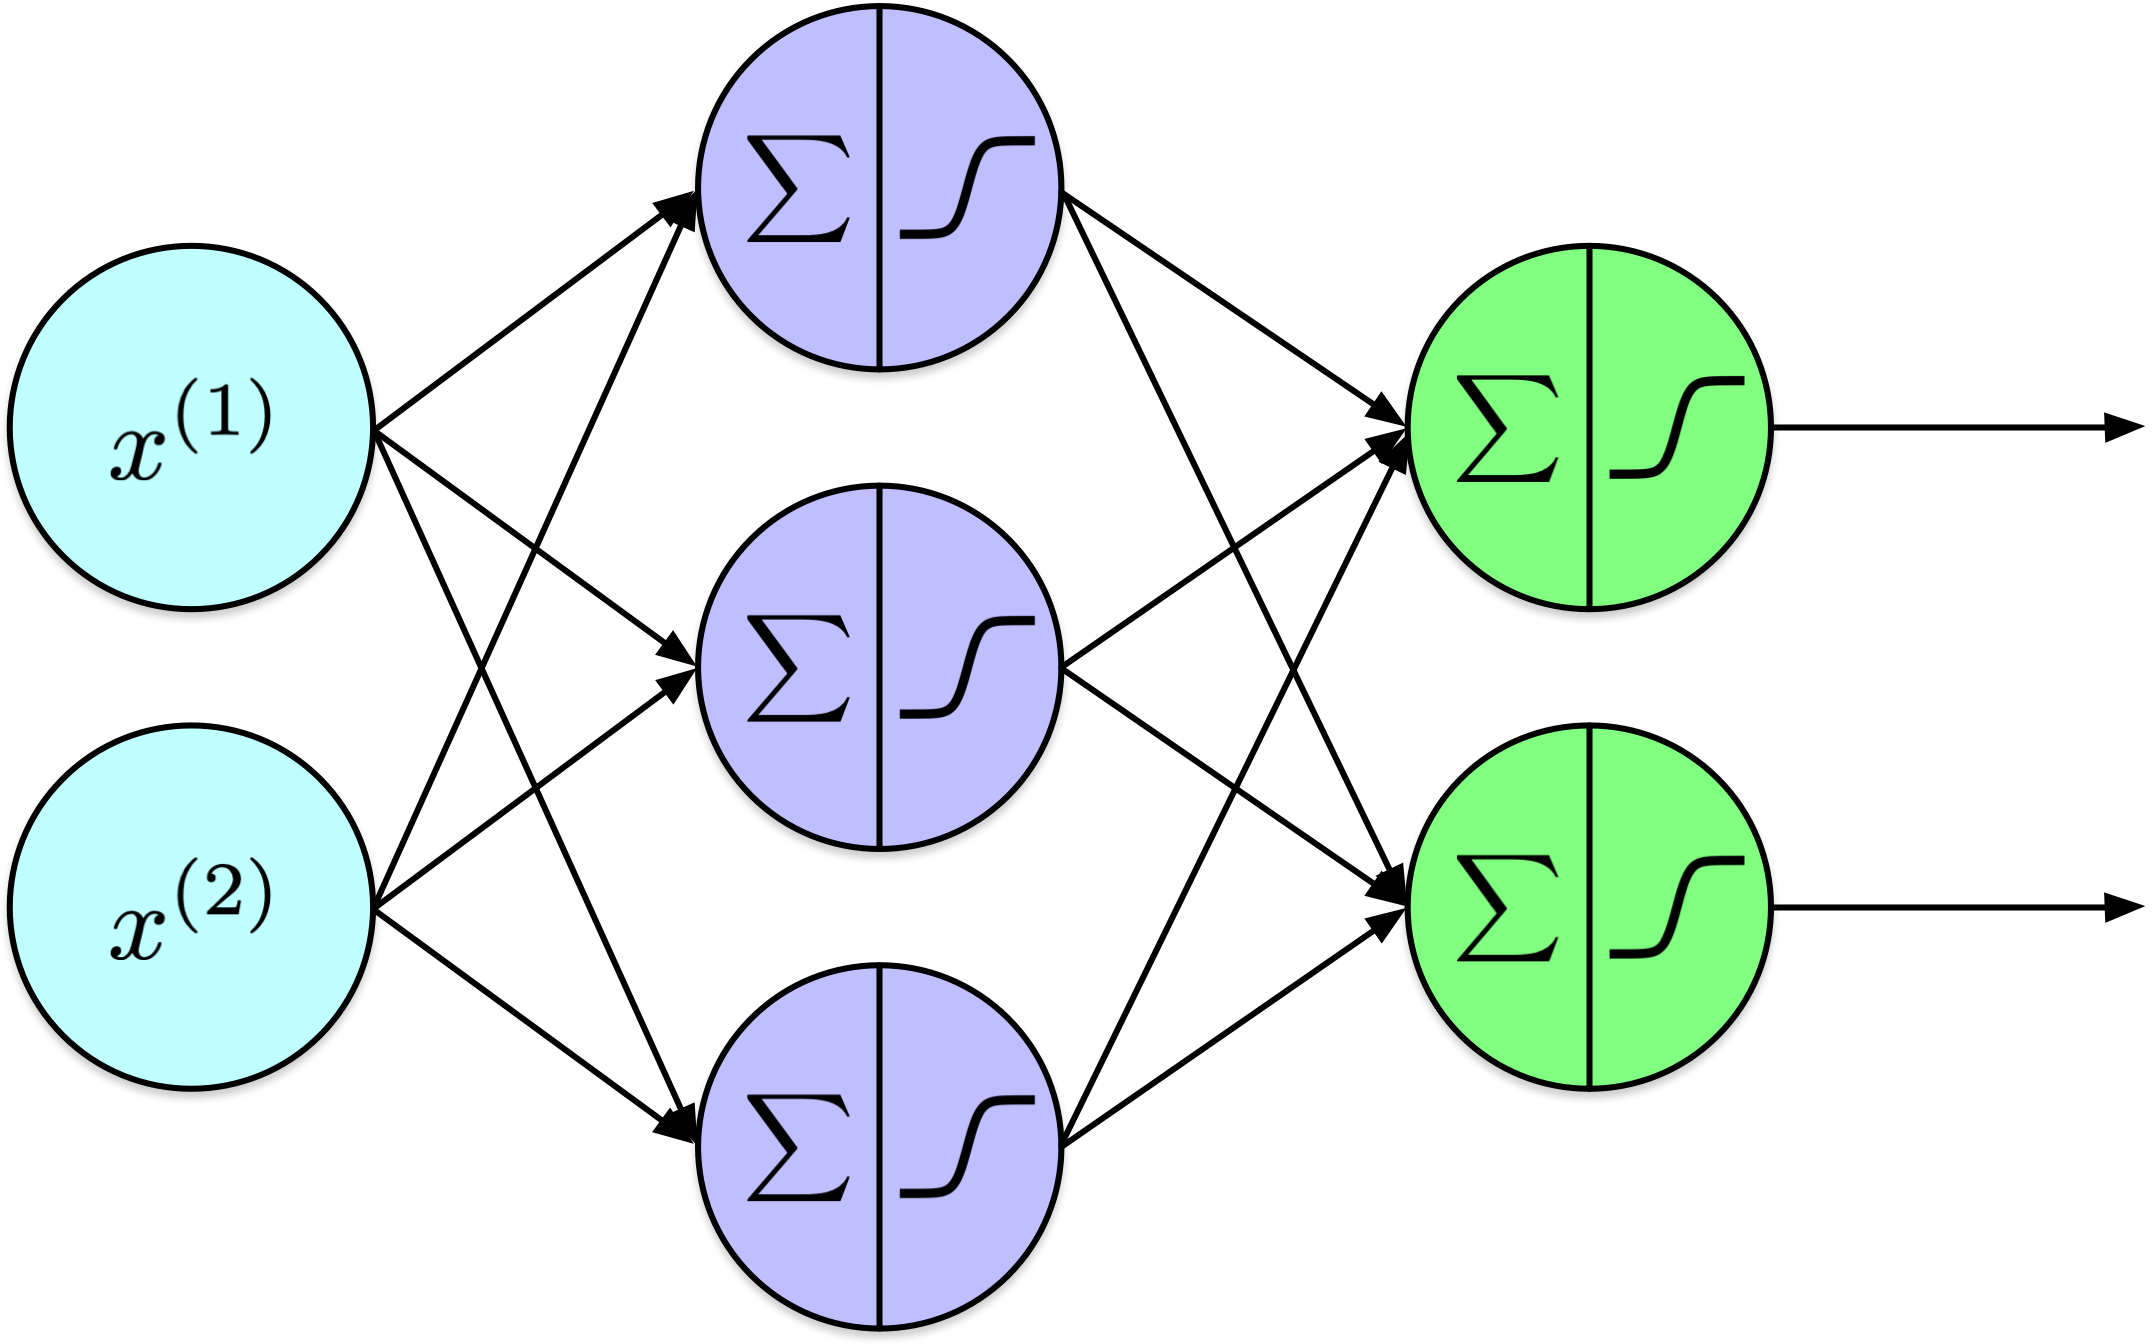

L’information dans cette architecture circule unidirectionnellement, de
gauche à droite, en passant de l’entrée à la sortie. Par conséquent, on
parle d’un **réseau neuronal à propagation directe (FNN)**.

Les réseaux neuronaux ont des **entrées** et des **sorties**.

Le réseau est composé de **trois couches** : d’entrée, cachée et de
sortie. La **couche d’entrée** contient deux nœuds, la **couche cachée**
en compte trois, et la **couche de sortie** en compte deux. Des couches
cachées supplémentaires et des nœuds par couche peuvent être ajoutés, ce
qui sera discuté plus tard.

Il est souvent utile d’inclure explicitement des nœuds d’entrée qui ne
font pas de calculs, appelés **unités d’entrée** ou **neurones
d’entrée**. Ces nœuds agissent comme des points d’insertion des
attributs d’entrée dans le réseau, passant les données directement à la
couche suivante sans transformation. Dans le diagramme du réseau, ce
sont les nœuds bleus clairs à gauche. En général, **le nombre d’unités
d’entrée correspond au nombre de attributs**.

## Résumé - FNN

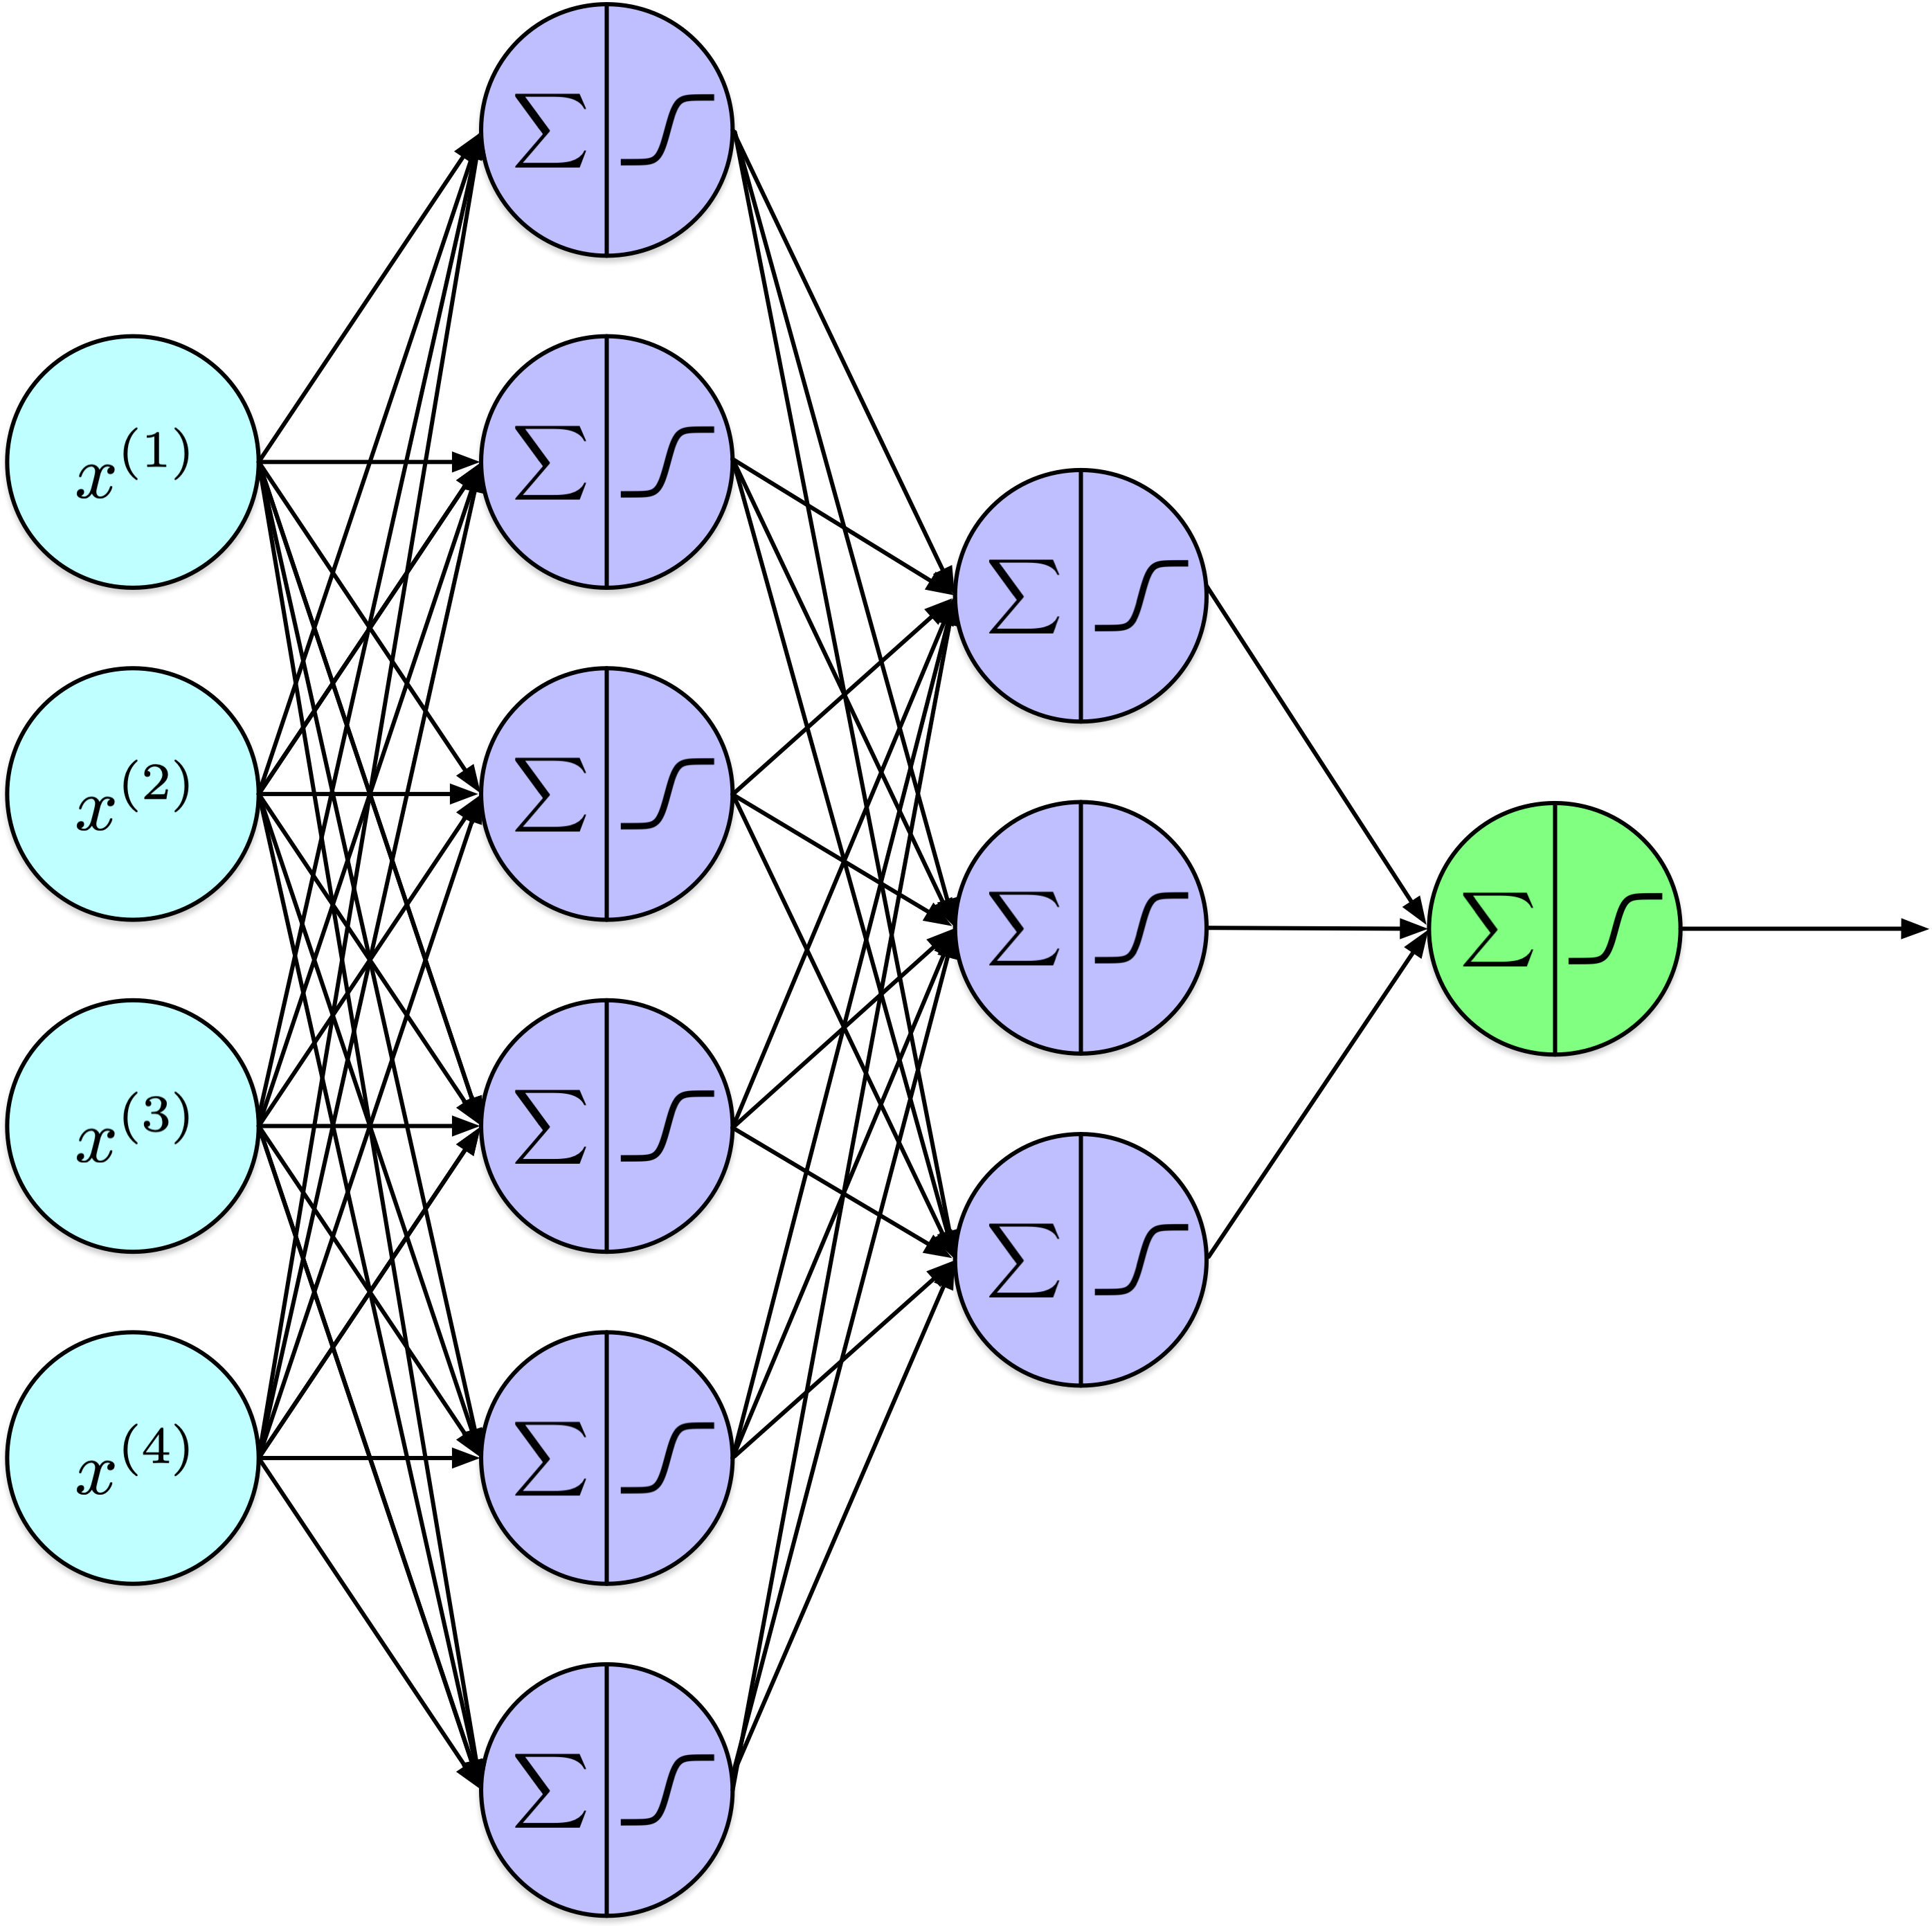

Le nombre de **couches** et de **nœuds** peut varier en fonction des
besoins spécifiques.

Les réseaux neuronaux peuvent avoir un nombre considérable de nœuds
d’entrée, souvent dans les centaines ou les milliers, selon la
complexité des données. Ils peuvent également contenir de nombreuses
couches cachées. Par exemple, ResNet, qui a remporté la tâche de
classification d’images de l’ILSVRC 2015, comporte 152 couches. Les
auteurs de ResNet ont démontré des résultats pour des réseaux avec 100
et même 1000 couches (He et al. 2016). Cependant, le nombre de nœuds de
sortie tend à être relativement petit. Dans les problèmes de régression,
il y a généralement un nœud de sortie, tandis que dans les tâches de
classification (multiclasse ou multilabel), le nombre de nœuds de sortie
correspond au nombre de classes.

## Résumé - unités

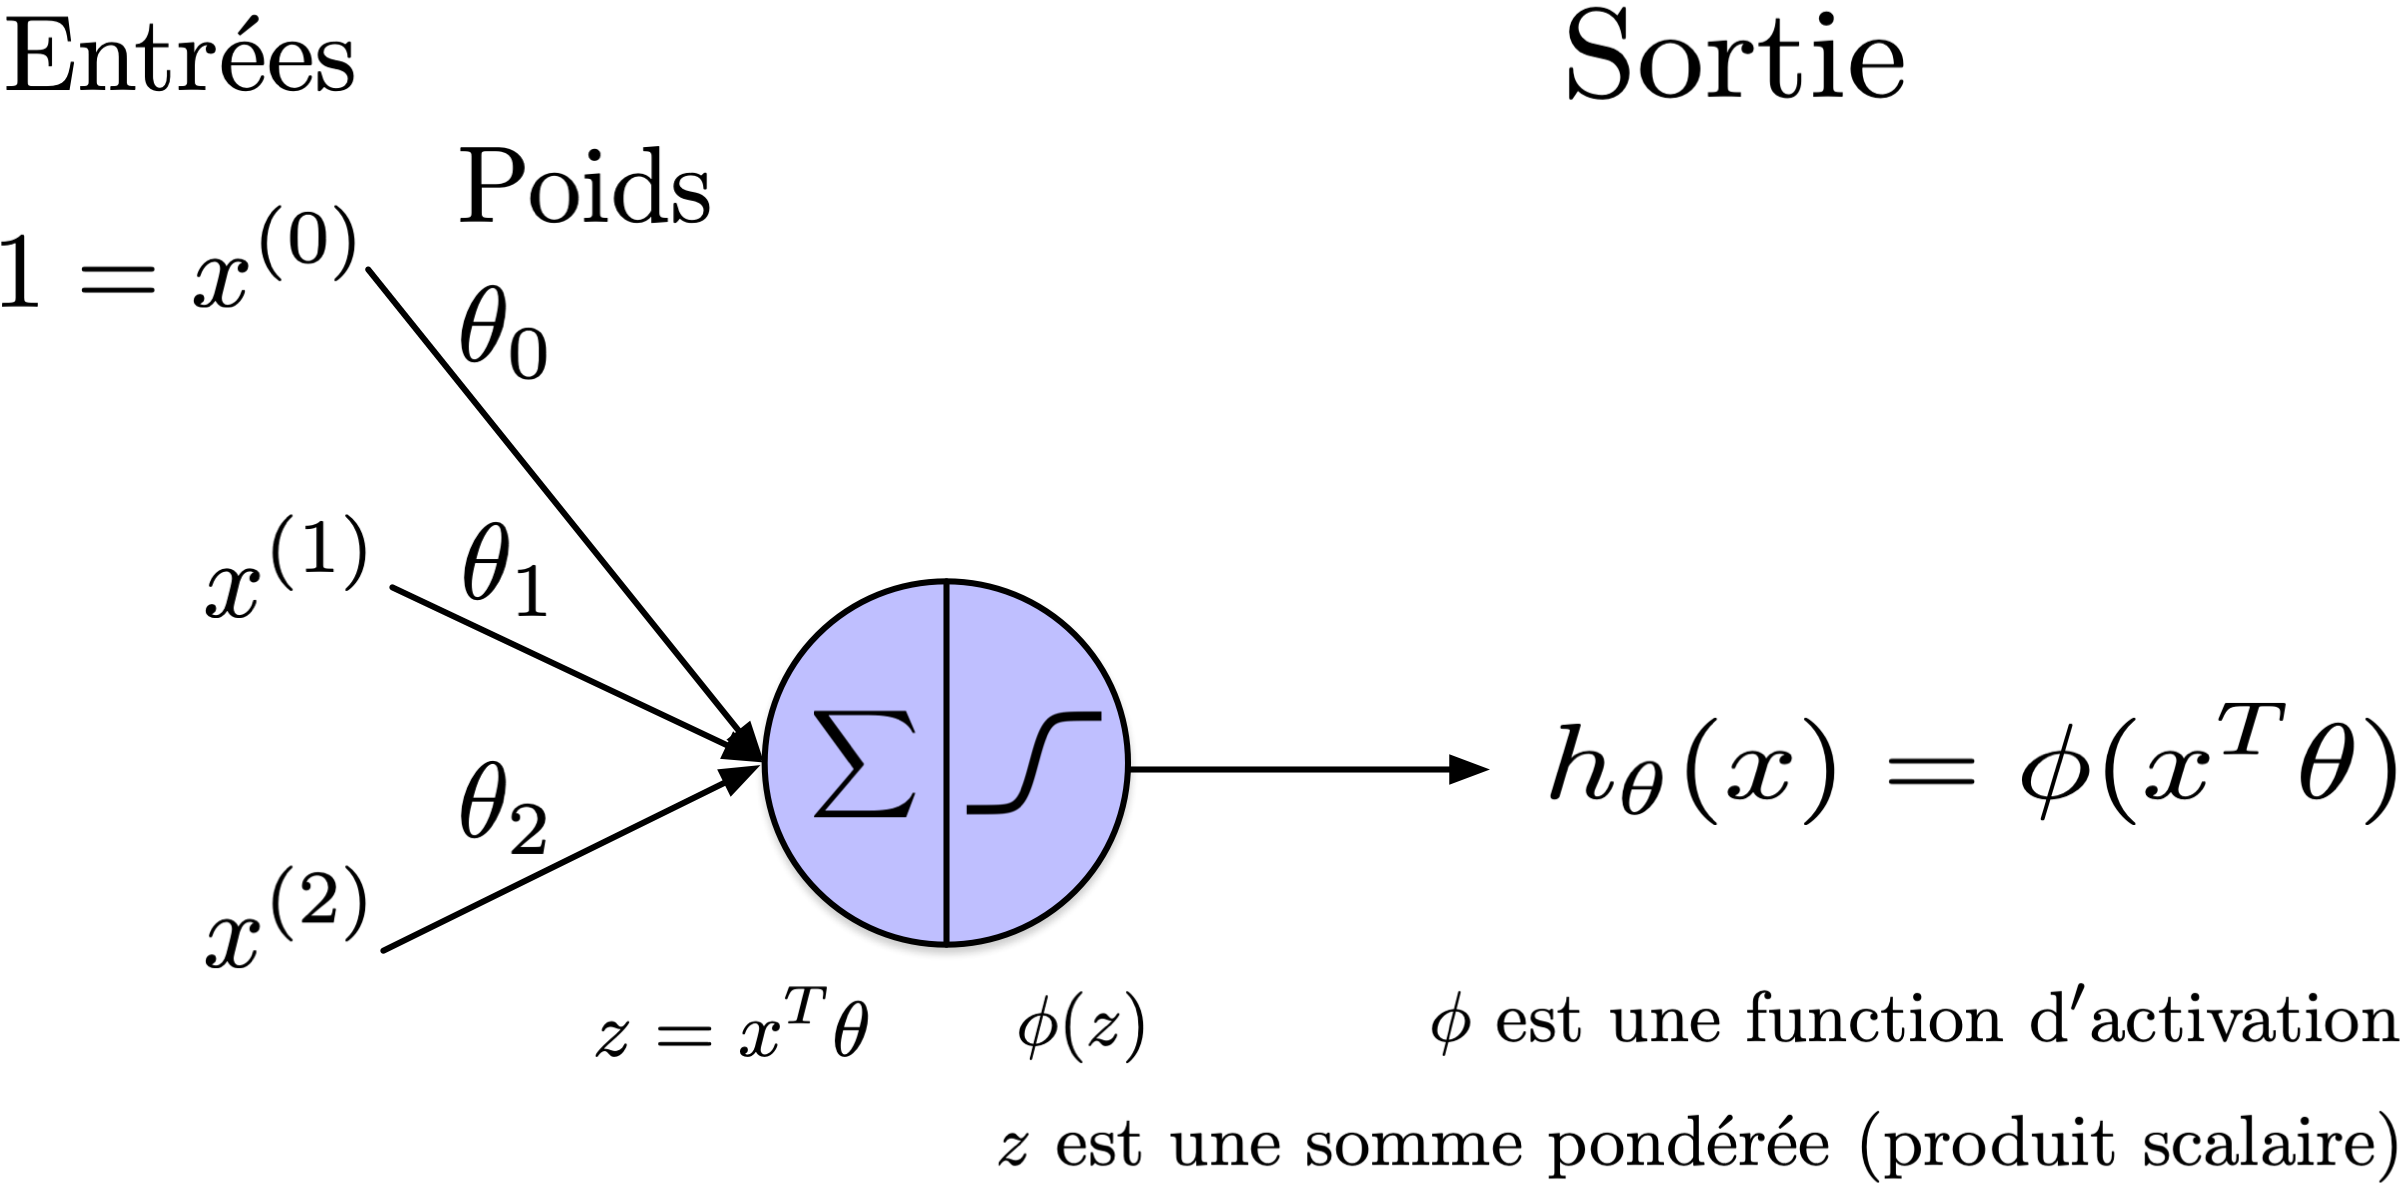

L’introduction d’une entrée fictive $x^{(0)} = 1$ est un *hack* qui
simplifie l’expression $x^T\theta + b$.

Dans le diagramme ci-dessus, il est important de préciser que les
entrées et la sortie concernent spécifiquement cette unité individuelle,
plutôt que les entrées globales et la sortie du réseau entier.

Le nom **activation** provient du rôle de la fonction dans la
détermination de l’activation ou non d’un neurone en fonction de son
entrée.

Historiquement, le concept s’inspire des neurones biologiques, où un
neurone s’active et transmet un signal à d’autres neurones si son entrée
dépasse un certain seuil. Dans les réseaux neuronaux artificiels, la
fonction d’activation joue un rôle similaire en introduisant de la
non-linéarité dans le modèle. Cette non-linéarité est cruciale car elle
permet au réseau d’apprendre des modèles complexes et des
représentations dans les données.

## Fonctions d’activation courantes

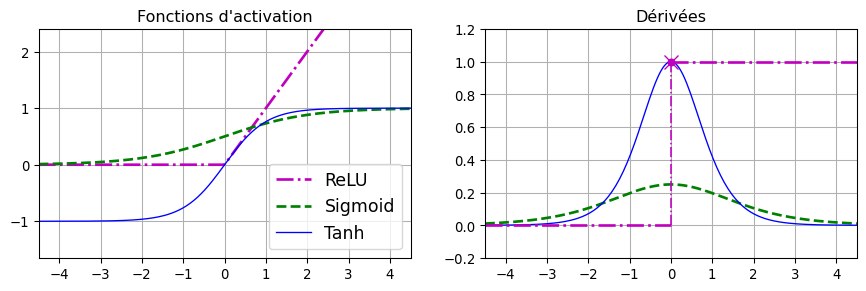

Géron (2022) –
[10_neural_nets_with_keras.ipynb](https://github.com/ageron/handson-ml3/blob/main/10_neural_nets_with_keras.ipynb)

Quelques observations importantes :

-   La fonction sigmoid produit des sorties dans l’intervalle ouvert
    $(0, 1)$.
-   La fonction tangente hyperbolique ($\tanh$) a une image s’étendant
    dans l’intervalle ouvert $(-1, 1)$.
-   La fonction d’unité linéaire rectifiée (ReLU) génère des valeurs
    dans l’intervalle $[0, \infty)$.

De plus, notez :

-   La valeur maximale de la dérivée de la fonction sigmoid est 0,25.
-   La valeur maximale de la dérivée de la fonction $\tanh$ est 1.
-   La dérivée de la fonction ReLU est 0 pour les entrées négatives et 1
    pour les entrées positives.

En outre :

-   Un nœud utilisant ReLU comme fonction d’activation génère des
    sorties dans la plage $[0, \infty)$. Cependant, sa dérivée, utilisée
    dans la descente de gradient pendant la rétropropagation, est
    constante et prend les valeurs de 0 ou 1.

## Approximation Universelle

Le **théorème de l’approximation universelle** stipule qu’un réseau
neuronal à propagation directe avec une seule couche cachée contenant un
nombre fini de neurones peut **approximer n’importe quelle fonction
continue** sur un sous-ensemble compact de $\mathbb{R}^n$, à condition
que les poids et les fonctions d’activation appropriés soient utilisés.

Cybenko (1989); Hornik, Stinchcombe, et White (1989)

# Notation

## Notation

Un **perceptron à deux couches** calcule :

$$
  y = \phi_2(\phi_1(X))
$$

où

$$
  \phi_l(Z) = \phi(W_lZ_l + b_l)
$$

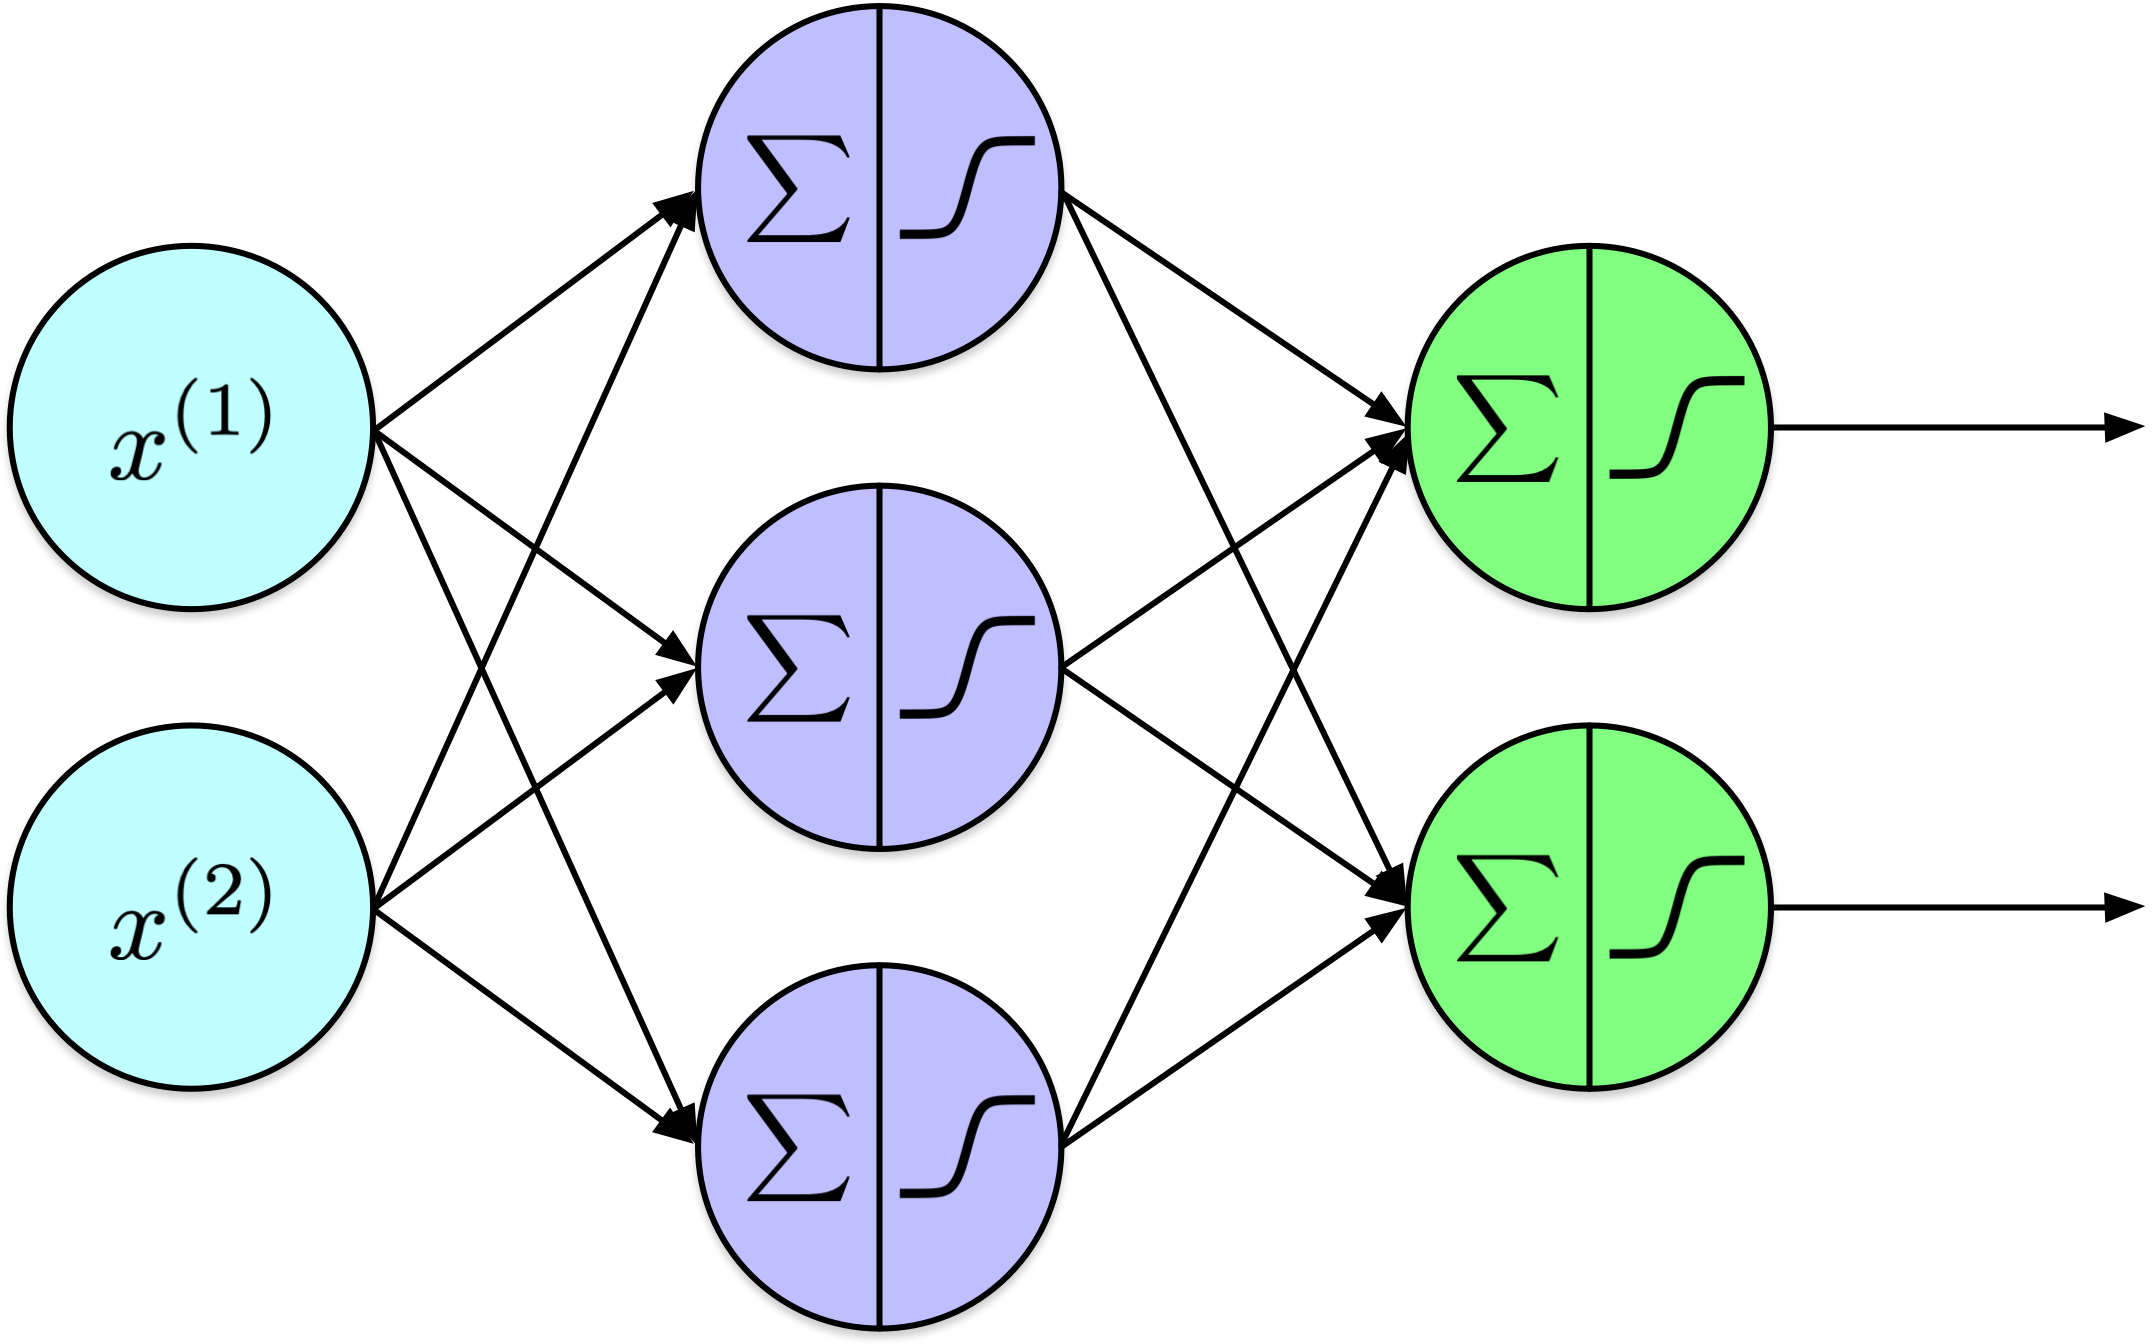

Où $\phi$ est une fonction d’activation, $W$ est une matrice de poids,
$X$ est une matrice d’entrée, et $b$ est un vecteur de biais.

## Notation

Un **perceptron à 3 couches** calcule :

$$
  y = \phi_3(\phi_2(\phi_1(X)))
$$

où

$$
  \phi_l(Z) = \phi(W_lZ_l + b_l)
$$

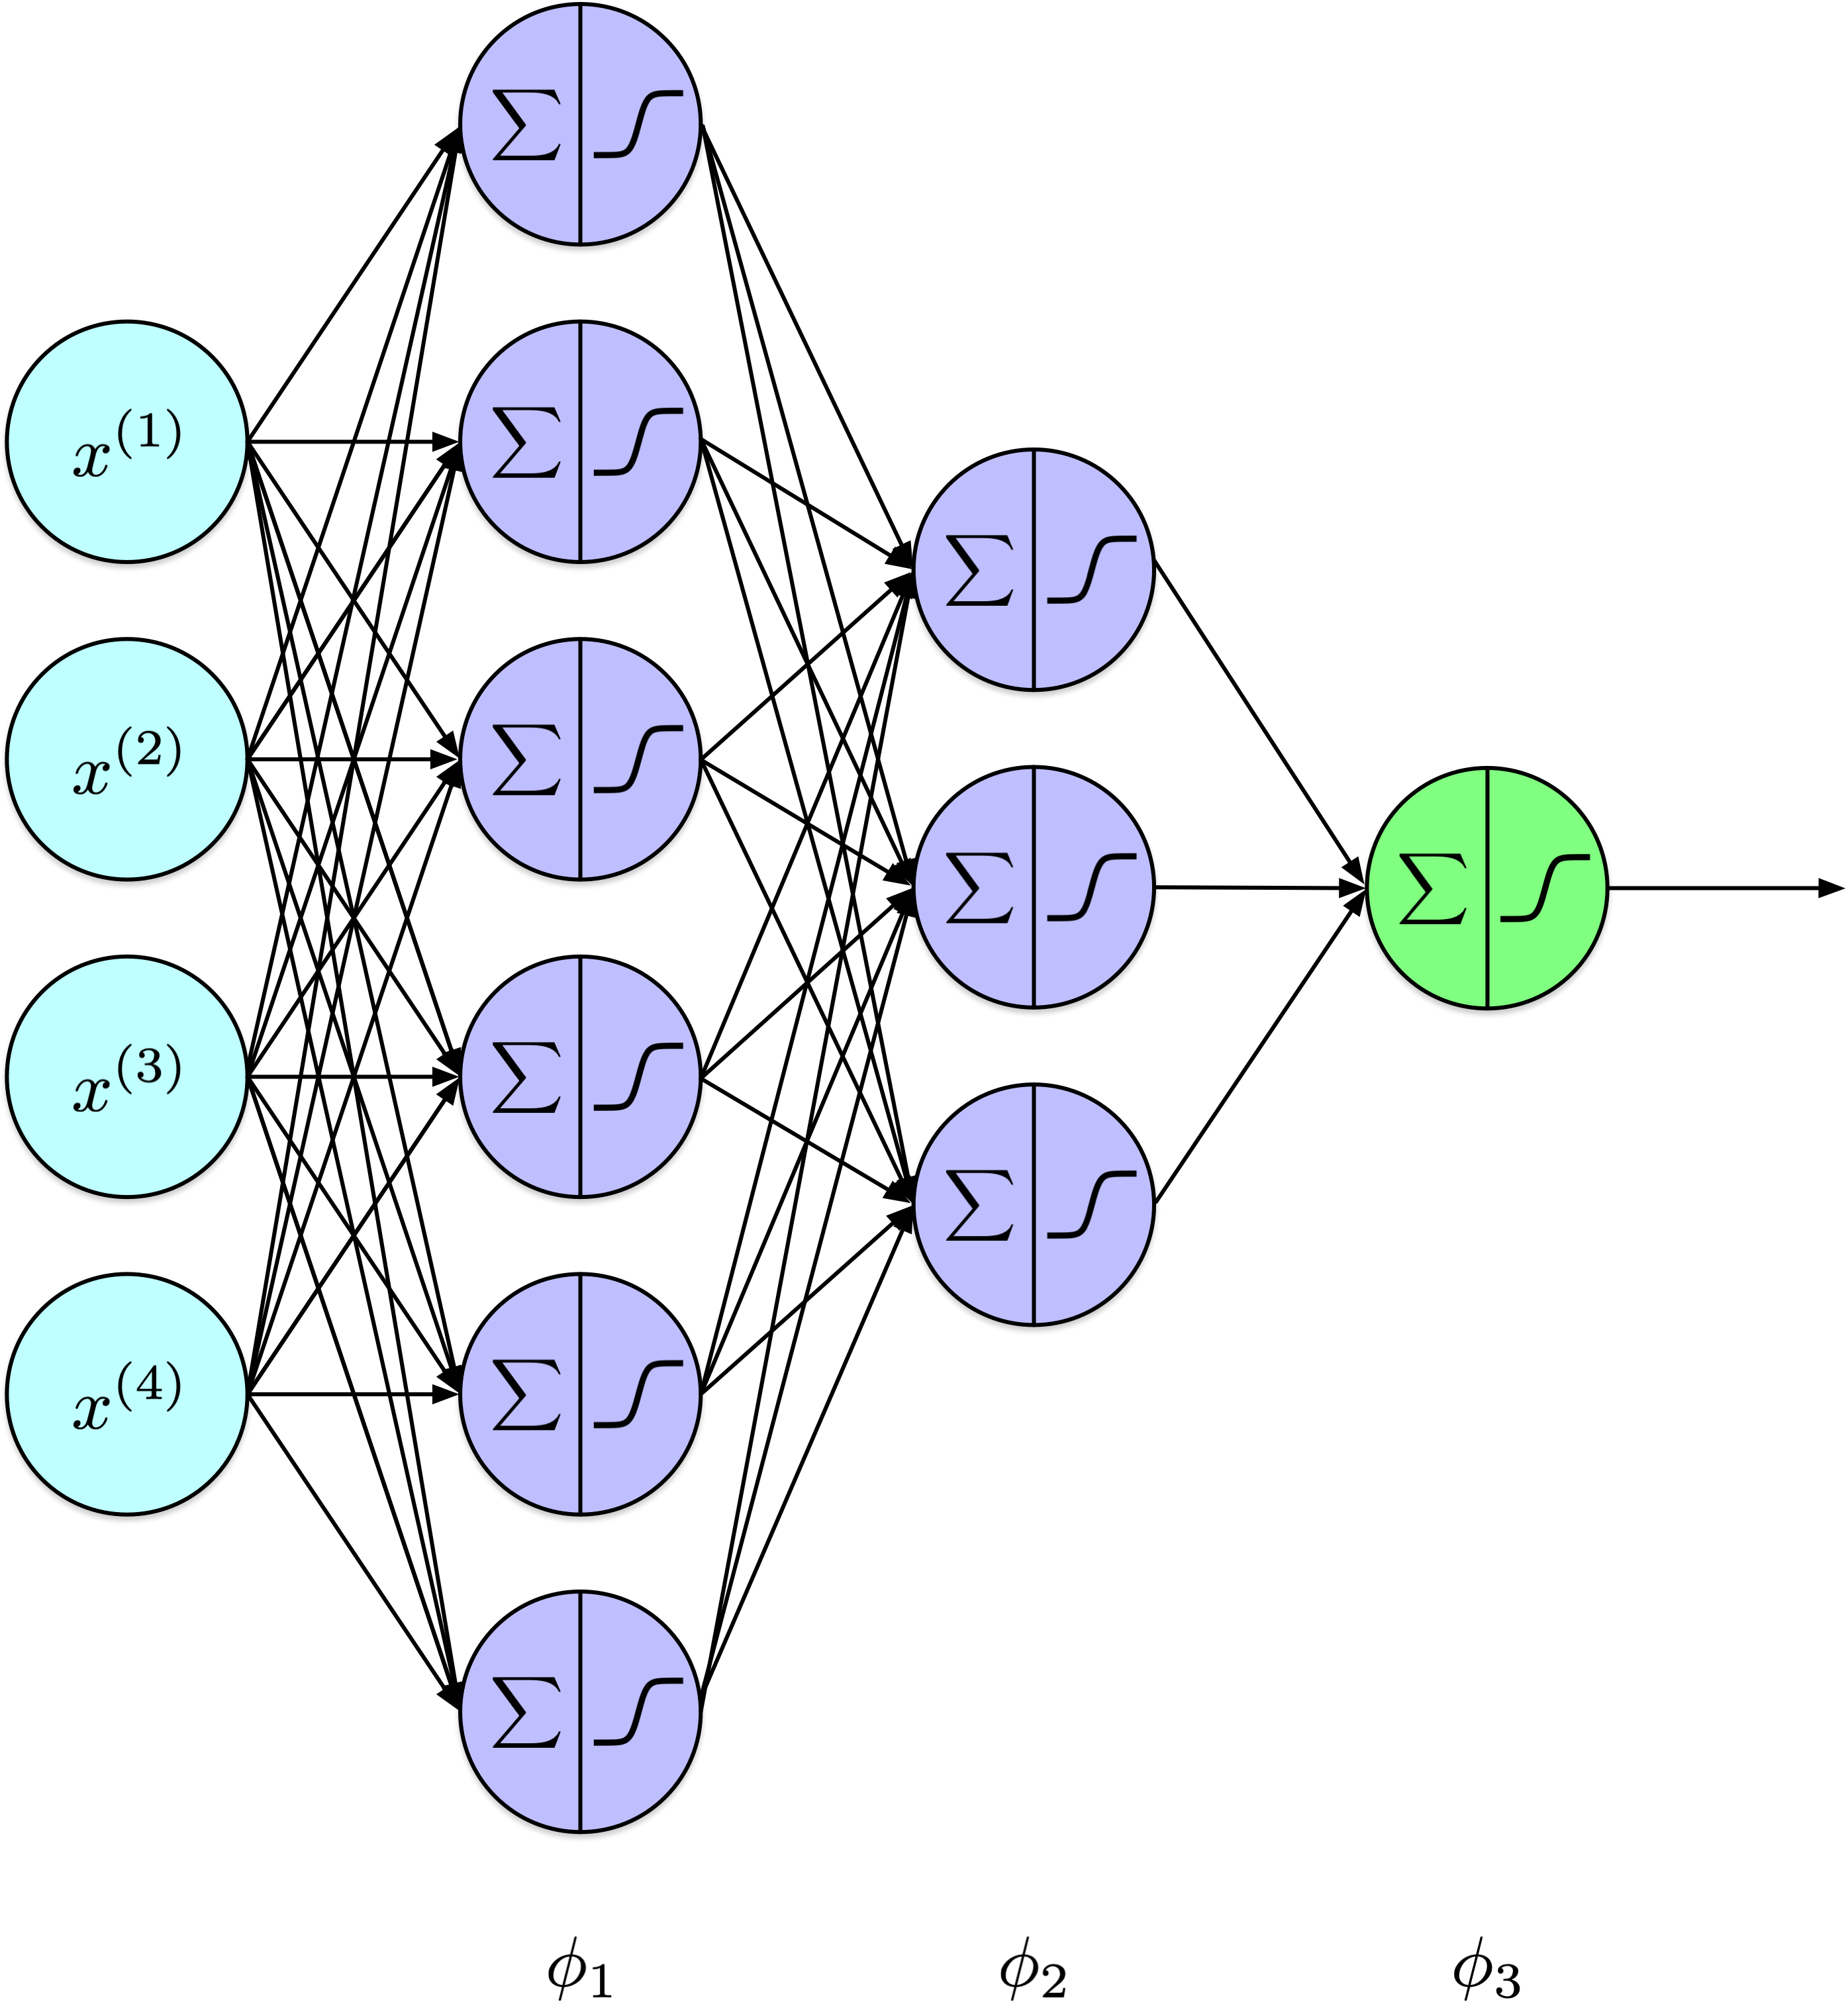

## Notation

Un perceptron à **$k$ couches** calcule :

$$
  y = \phi_k( \ldots \phi_2(\phi_1(X)) \ldots )
$$

où

$$
  \phi_l(Z) = \phi(W_lZ_l + b_l)
$$

Un réseau à propagation avant montre une structure cohérente où chaque
couche effectue le même type de calcul sur des entrées différentes. Plus
précisément, l’entrée de la couche $l$ est la sortie de la couche $l-1$.

# Rétropropagation

## 3Blue1Brown

<https://youtu.be/Ilg3gGewQ5U>

## Rétropropagation

**Apprentissage de représentations par rétropropagation des erreurs**

*David E. Rumelhart, <u>Geoffrey E. Hinton</u> & Ronald J. Williams*

Nous décrivons une nouvelle procédure d’apprentissage, la
rétropropagation, pour les réseaux de neurones simulant le comportement
des neurones biologiques. La procédure **ajuste à plusieurs reprises les
poids** des connexions dans le réseau afin de **minimiser une mesure de
la différence entre le vecteur de sortie réel du réseau et le vecteur de
sortie désiré**. À la suite de ces ajustements de poids, des unités
internes ‘**cachées**’, qui ne font pas partie de l’entrée ou de la
sortie, viennent **représenter des attributs importants du domaine de la
tâche**, et les régularités dans la tâche sont capturées par les
interactions de ces unités. La **capacité à créer de nouveaux attributs
utiles** distingue la rétropropagation des méthodes plus anciennes et
plus simples telles que la procédure de convergence du perceptron.

Rumelhart, Hinton, et Williams (1986)

Je présente ici l’abstract de l’article séminal publié dans Nature, où
Hinton et ses collègues ont introduit l’algorithme de rétropropagation.
Cet abstract est à la fois élégant et informatif, capturant efficacement
les principes fondamentaux des réseaux neuronaux modernes : le concept
de fonction de perte, l’ajustement itératif des poids via l’algorithme
de descente de gradient, et le rôle crucial des couches cachées dans la
génération de fonctionnalités utiles dépendantes de la tâche.

Nature est une revue prestigieuse, qui publie rarement du contenu en
informatique.

Au moment de cette publication, Hinton était affilié à l’Université
Carnegie Mellon. Pour rappel, Hinton a reçu le prix Nobel de Physique en
2024 pour ses contributions au développement des méthodes fondamentales
de l’apprentissage automatique moderne.

L’abstract met en lumière la raison d’être des couches cachées dans les
réseaux neuronaux. Les premières couches cachées apprennent des
représentations simples à partir des données d’entrée, tandis que les
couches suivantes identifient des associations entre ces
représentations. Chaque couche s’appuie sur les connaissances des
couches précédentes pour aboutir à la sortie finale du réseau.

## Avant la rétropropagation

-   Des limitations, comme **l’incapacité à résoudre la tâche de
    classification XOR**, ont **bloqué** la recherche sur les réseaux
    neuronaux.

-   Le perceptron était **limité à une seule couche**, et il n’existait
    **aucune méthode connue pour entraîner un perceptron multicouche**.

-   Les perceptrons monocouche sont limités à la résolution de tâches de
    classification **linéairement séparables**.

## Rétropropagation : contributions

-   Le modèle utilise la **moyenne des erreurs quadratiques** comme
    **fonction de perte**.

-   La **descente de gradient** est utilisée pour minimiser la
    **perte**.

-   Une **fonction d’activation sigmoid** est utilisée au lieu d’une
    fonction de seuil, car sa **dérivée** fournit des informations
    précieuses pour la descente de gradient.

-   Montre comment mettre à jour les **poids internes** en utilisant un
    algorithme à **deux passes** composé d’une passe **avant** et d’une
    passe **arrière**.

-   **Permet l’entraînement des perceptrons multicouches**.

## Rétropropagation : aperçu général

1.  **Initialisation**

2.  **Passe avant**

3.  **Calcul de la perte**

4.  **Passe arrière (Rétropropagation)**

5.  **Répéter les étapes 2 à 5**.

L’algorithme **s’arrête** soit après un **nombre prédéfini d’époques**,
soit lorsque les **critères de convergence sont satisfaits**.

## Rétropropagation : 1. Initialisation

Initialiser les **poids** et **biais** du réseau neuronal.

1.  **~~Initialisation à zéro~~**
    -   Tous les poids sont **initialisés à zéro**.
    -   Problèmes de symétrie : **tous les neurones produisent des
        sorties identiques**, empêchant un apprentissage efficace.
2.  **Initialisation aléatoire**
    -   Les poids sont initialisés **aléatoirement**, souvent avec une
        distribution **uniforme** ou **normale**.
    -   **Brise la symétrie entre les neurones**, leur permettant
        d’apprendre.
    -   Si elle n’est pas bien ajustée, peut entraîner une **convergence
        lente** ou des **gradients qui disparaissent/explosent**.

**Voir aussi** : Initialisation Xavier/Glorot et He (plus tard)

L’initialisation à zéro fonctionne pour la régression logistique, car il
s’agit d’un modèle linéaire avec une seule couche. Dans la régression
logistique, chaque poids est ajusté indépendamment pendant
l’entraînement, et le processus d’optimisation peut converger
correctement, à condition que les données soient linéairement
séparables.

Cependant, l’initialisation à zéro ne fonctionne pas bien pour les
réseaux neuronaux en raison de leur structure multicouche. Voici
pourquoi :

1.  **Rupture de la symétrie** : Les réseaux neuronaux nécessitent de
    rompre la symétrie entre les neurones dans chaque couche pour qu’ils
    puissent apprendre différents attributs. Si tous les poids sont
    initialisés à zéro, chaque neurone d’une couche calculera la même
    sortie et recevra le même gradient pendant la rétropropagation. Cela
    entraîne une mise à jour identique des neurones, les empêchant
    d’apprendre des attributs distinctes, rendant ainsi plusieurs
    neurones redondants.

2.  **Non-linéarité** : Les réseaux neuronaux reposent sur des
    transformations non linéaires entre les couches pour modéliser des
    relations complexes dans les données. L’initialisation à zéro inhibe
    la capacité des neurones à s’activer différemment, empêchant le
    réseau de capturer des modèles non linéaires.

## Rétropropagation : 2. Passe avant

**Pour chaque exemple** dans l’ensemble d’entraînement (ou dans un
mini-lot) :

-   **Couche d’entrée** : Passez les attributs d’entrée à la première
    couche.

-   **Couches cachées** : Pour chaque couche cachée, calculez les
    **activations** (sortie) en appliquant la **somme pondérée des
    entrées plus le biais**, suivie d’une **fonction d’activation** (par
    exemple, sigmoid, ReLU).

-   **Couche de sortie** : Même processus que pour les couches cachées.
    Les activations de la couche de sortie représentent les valeurs
    prédites.

La passe avant est presque identique à l’application du réseau pour la
prédiction (`.predict()`), à l’exception que les résultats
intermédiaires (activations) sont enregistrés, car ils sont nécessaires
pour la passe arrière.

En pratique, c’est la version mini-lot de cet algorithme qui est
utilisée.

## Rétropropagation : 3. Calcul de la perte

Calculez la **perte** (**erreur**) à l’aide d’une fonction de perte
appropriée en comparant les **valeurs prédites** aux **valeurs cibles
réelles**.

Nous aborderons plus tard les différentes fonctions de perte : **moyenne
des erreurs quadratiques** pour les tâches de régression ou **perte
d’entropie croisée** pour les tâches de classification.

Une perte plus faible indique que les valeurs prédites sont plus proches
des valeurs cibles réelles.

La valeur de la fonction de perte peut servir de critère d’arrêt, la
rétropropagation s’arrêtant lorsque la perte est suffisamment faible.

La dérivée de la fonction de perte fournit des informations essentielles
pour ajuster les poids et les biais du réseau.

## Rétropropagation : 4. Passe arrière

-   **Couche de sortie** : Calculez le **gradient de la perte** par
    rapport aux **poids** et aux **biais** de la couche de sortie en
    utilisant la **règle de chaîne** du calcul.

-   **Couches cachées** : **Propagez l’erreur en arrière** à travers le
    réseau, **couche par couche**. Pour chaque couche, calculez le
    gradient de la perte par rapport aux poids et biais. Utilisez la
    dérivée de la fonction d’activation pour aider à calculer ces
    gradients.

-   **Mettre à jour les poids et biais** : Ajustez les poids et biais en
    utilisant les gradients calculés et un taux d’apprentissage, qui
    détermine la taille des ajustements.

Les techniques d’optimisation courantes comme **la descente de
gradient** ou ses variantes (par exemple, Adam) sont utilisées.

À la fin de la présentation, des liens vers une série de vidéos de
Herman Kamper sont fournis. Ces vidéos expliquent en détail l’algorithme
de rétropropagation à travers diverses architectures, avec ou sans
bifurcations, en utilisant la composition de fonctions et les graphes de
calcul.

Bien que l’algorithme soit complexe en raison des nombreux cas qu’il
englobe, sa structure régulière le rend propice à l’automatisation. En
particulier, les algorithmes comme la différenciation automatique
(autodiff) facilitent ce processus.

En 1970, [Seppo Ilmari
Linnainmaa](https://en.wikipedia.org/wiki/Seppo_Linnainmaa) a introduit
l’algorithme connu sous le nom de différenciation automatique en mode
inverse dans sa thèse de MSc. Bien qu’il ne l’ait pas appliqué aux
réseaux neuronaux, il est plus général que la rétropropagation.

## Concepts clés

-   **Fonctions d’activation** : Des fonctions comme sigmoid, ReLU et
    tanh introduisent de la non-linéarité, permettant au réseau
    d’apprendre des modèles complexes.

-   **Taux d’apprentissage** : Un hyperparamètre qui contrôle de combien
    on modifie le modèle en réponse à l’erreur estimée chaque fois que
    les poids du modèle sont mis à jour.

-   **Descente de gradient** : Un algorithme d’optimisation utilisé pour
    minimiser la fonction de perte en se déplaçant itérativement vers la
    plus grande descente définie par le négatif du gradient.

## Résumé

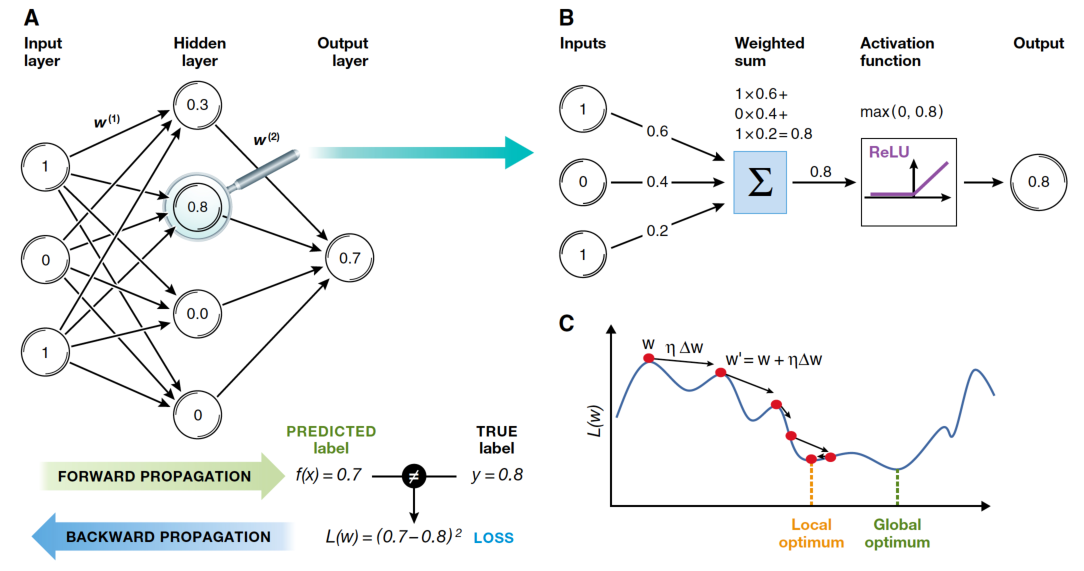

**Attribution** : Angermueller et al. (2016)

# Entraînement

## Gradients qui disparaissent

-   **Problème des gradients qui disparaissent** (*vanishing gradients*)
    : Les gradients deviennent trop petits, **entravant la mise à jour
    des poids**.

-   La recherche sur les réseaux neuronaux a **de nouveau stagné** au
    début des années 2000.

-   La **sigmoid** et sa dérivée (plage : 0 à 0,25) étaient des facteurs
    clés.

-   **Initialisation courante** : Les poids/biais de $\mathcal{N}(0, 1)$
    ont contribué au problème.

Glorot et Bengio (2010) a mis en lumière ces problèmes.

Le problème des gradients qui disparaissent se produit souvent avec des
fonctions d’activation comme la sigmoid et la tangente hyperbolique
(tanh), ce qui rend difficile l’entraînement des réseaux neuronaux
profonds en raison des gradients qui diminuent, ralentissant ainsi
l’apprentissage.

En revanche, le problème des gradients explosifs, où les gradients
deviennent excessivement grands, est généralement observé dans des
architectures telles que les réseaux neuronaux récurrents (RNN).

Ces deux problèmes peuvent affecter de manière significative la
stabilité et la convergence des techniques d’optimisation basées sur les
gradients, compromettant ainsi l’entraînement efficace des modèles
profonds.

## Glorot et Bengio

Figure 6

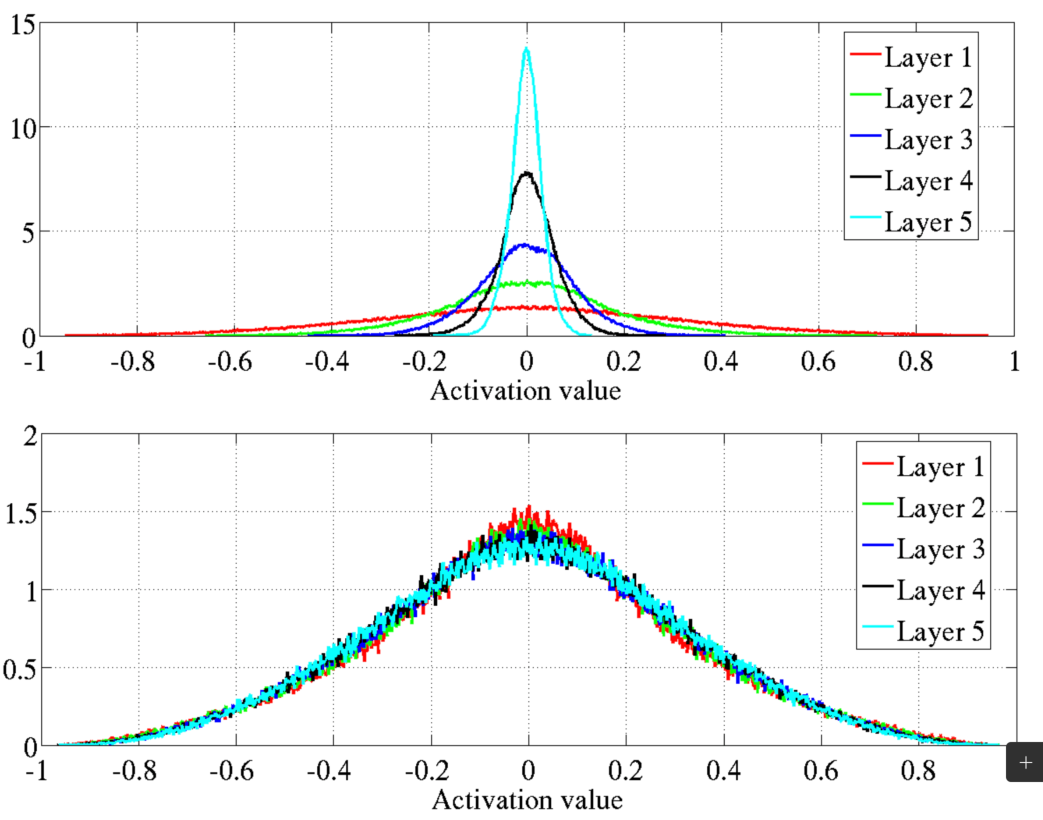

Figure 7

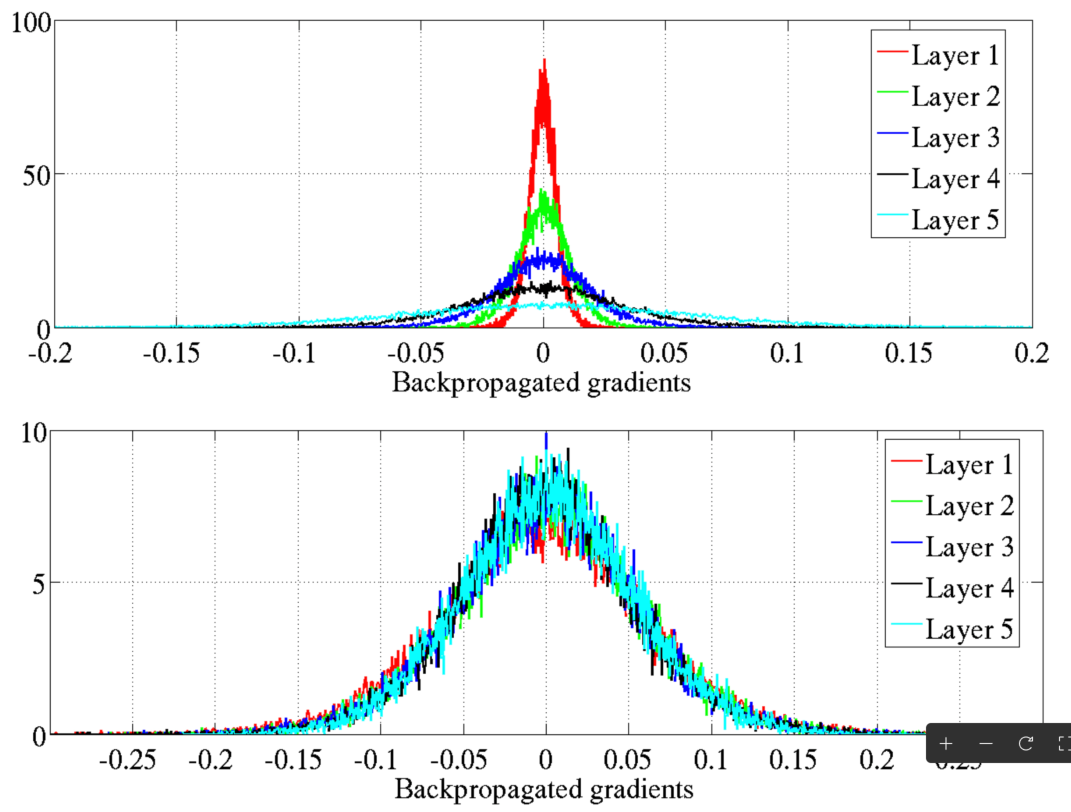

Glorot et Bengio (2010), page 254.

Les graphiques présentés illustrent les histogrammes normalisés des
valeurs d’activation et des gradients rétropropagés associés à la
fonction d’activation tangente hyperbolique.

Pour produire les diagrammes du haut, Glorot et Bengio ont utilisé une
méthode d’initialisation qui était populaire à l’époque, tandis que les
diagrammes du bas ont été réalisés en utilisant un nouveau schéma
(Glorot).

## Gradients qui disparaissent : solutions

-   **Fonctions d’activation alternatives** : Unité linéaire rectifiée
    (**ReLU**) et ses variantes (par exemple, **Leaky ReLU**,
    **Parametric ReLU**, et **Exponential Linear Unit**).

-   **Initialisation des poids** : Initialisation Xavier (Glorot) ou He.

D’autres techniques existent pour atténuer ce problème, notamment :

-   **Normalisation par lot (Batch Normalization)** : Implémentez la
    normalisation par lot pour standardiser les entrées de chaque
    couche, ce qui peut aider à stabiliser et accélérer l’entraînement
    en réduisant le décalage covariant interne et en maintenant un flux
    de gradient efficace.

-   **Réseaux résiduels (Residual Networks)** : Utilisez des connexions
    résiduelles, comme dans les architectures ResNet, qui permettent aux
    gradients de circuler plus facilement à travers le réseau en
    fournissant des chemins de raccourci qui contournent une ou
    plusieurs couches.

## Glorot et Bengio

**Objectif :** Atténuer le problème des gradients instables dans les
réseaux neuronaux profonds.

**Flux de signal :**

-   **Direction avant** : Assurer une propagation stable du signal pour
    des prédictions précises.
-   **Direction arrière** : Maintenir un flux de gradient cohérent
    pendant la rétropropagation.

Glorot et Bengio (2010) : prêtez attention au flux de signal dans les
deux directions !

## Glorot et Bengio

**Ajustement de la variance** :

-   **Passe avant** : Assurez-vous que la variance de sortie de chaque
    couche correspond à la variance d’entrée.

-   **Passe arrière** : Maintenez une variance de gradient égale avant
    et après le passage dans chaque couche.

Keras utilise par défaut l’initialisation Glorot, bien adaptée aux
fonctions d’activation telles que **sigmoid**, **tanh**, et **softmax**.

## Initialisation He

Une méthode d’initialisation similaire mais légèrement différente,
conçue pour fonctionner avec **ReLU**, ainsi que **Leaky ReLU**,
**ELU**, **GELU**, **Swish**, et **Mish**.

. . .

Assurez-vous que la méthode d’initialisation **correspond** à la
fonction d’activation choisie.

In [2]:
import tensorflow as tf
from tensorflow.python.keras.layers import Dense

dense = Dense(50, activation="relu", kernel_initializer="he_normal")

Aussi appelée initialisation Kaiming.

-   **Initialisation Glorot (Initialisation Xavier)** : Cette méthode
    ajuste les poids initiaux en fonction du nombre d’unités d’entrée et
    de sortie pour chaque couche, dans le but de maintenir la variance
    des activations cohérente à travers les couches. Elle est
    particulièrement efficace pour les fonctions d’activation comme
    sigmoid et tanh.

-   **Initialisation He** : Cette approche ajuste l’initialisation des
    poids pour être adaptée aux couches utilisant ReLU et ses variantes,
    en ajustant la variance selon le nombre d’unités d’entrée
    uniquement.

## Note

L’initialisation aléatoire des poids[1] suffit à **briser la symétrie**
dans un réseau neuronal, permettant ainsi de **fixer les termes de biais
à zéro** sans nuire à la capacité d’apprentissage du réseau.

## Fonction d’activation : Leaky ReLU

[1] Une initialisation correcte des poids, telle que l’initialisation
Xavier/Glorot ou He, est cruciale et doit être alignée avec le choix de
la fonction d’activation pour garantir des performances optimales du
réseau.

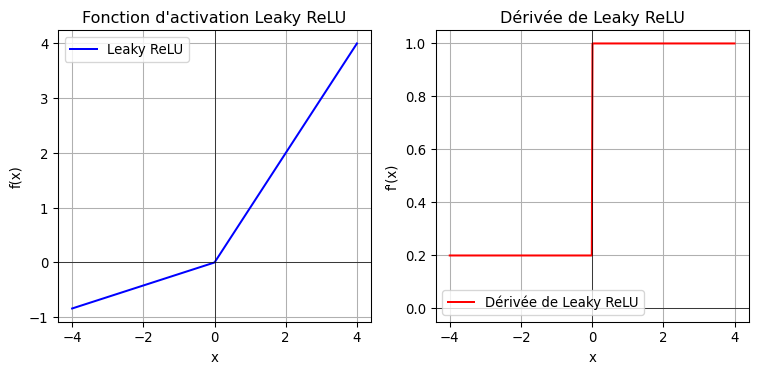

Le Leaky ReLU, une variante de la fonction d’activation ReLU standard,
atténue efficacement le problème des neurones *morts*. Pour les valeurs
d’entrée négatives, il introduit une composante linéaire avec une pente
régie par le paramètre `negative_slope`.

Lorsque l’entrée de la fonction ReLU, la somme pondérée plus le biais,
est négative pour tous les exemples d’entraînement, la valeur de sortie
de ReLU est zéro. Mais aussi, sa dérivée est 0, ce qui désactive
effectivement le neurone. Le Leaky ReLU, ou d’autres variantes, atténue
efficacement ce problème.

``` python
import tensorflow as tf
from tensorflow.python.keras.layers import Dense

leaky_relu = tf.keras.layers.LeakyReLU(negative_slope=0.2)
dense = tf.keras.layers.Dense(50, activation=leaky_relu, kernel_initializer="he_normal")
```

Keras propose 18 [fonctions d’activation de
couche](https://keras.io/api/layers/activations/#available-activations)
au moment de la rédaction.

# Prologue

## Résumé

-   **Réseaux neuronaux artificiels (ANNs)** :
    -   Inspirés des réseaux neuronaux biologiques.
    -   Composés de neurones interconnectés organisés en couches.
    -   Applicables à l’apprentissage supervisé, non supervisé, et par
        renforcement.
-   **Réseaux neuronaux à propagation directe (FNNs)** :
    -   L’information circule unidirectionnellement de l’entrée à la
        sortie.
    -   Composés de couches d’entrée, cachées et de sortie.
    -   Le nombre de couches et de neurones par couche peut varier.
-   **Fonctions d’activation** :
    -   Introduisent de la non-linéarité pour permettre l’apprentissage
        de modèles complexes.
    -   Fonctions courantes : Sigmoid, Tanh, ReLU, Leaky ReLU.
    -   Le choix de la fonction d’activation affecte le flux de gradient
        et les performances du réseau.
-   **Algorithme de rétropropagation** :
    -   L’entraînement implique une passe avant, un calcul de perte, une
        passe arrière et une mise à jour des poids.
    -   Utilise la descente de gradient pour minimiser la fonction de
        perte.
    -   Permet l’entraînement des perceptrons multicouches en ajustant
        les poids internes.
-   **Problème du gradient qui disparaît** :
    -   Les gradients deviennent trop petits lors de la
        rétropropagation, ce qui freine l’entraînement.
    -   Stratégies de mitigation : utilisation de fonctions d’activation
        ReLU et d’une initialisation correcte des poids (Glorot ou He).
-   **Initialisation des poids** :
    -   L’initialisation aléatoire brise la symétrie et permet un
        apprentissage efficace.
    -   L’initialisation Glorot convient aux activations sigmoid et
        tanh.
    -   L’initialisation He est optimale pour ReLU et ses variantes.
-   **Concepts clés** :
    -   Le taux d’apprentissage détermine la taille des pas pendant
        l’optimisation.
    -   La descente de gradient est utilisée pour mettre à jour les
        poids en minimisant la perte.
    -   Le choix des fonctions d’activation et des méthodes
        d’initialisation est crucial pour un entraînement efficace.

## 3Blue1Brown

Une série de vidéos, avec des animations, offrant l’**intuition**
derrière l’**algorithme de rétropropagation**.

-   [Neural
    networks](https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi)
    (playlist)

    -   [What is backpropagation really
        doing?](https://www.youtube.com/watch?v=Ilg3gGewQ5U&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=3&t=212s)
        (12m 47s)
    -   [Backpropagation
        calculus](https://www.youtube.com/watch?v=tIeHLnjs5U8&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=4)
        (10m 18s)

Prérequis : [Gradient descent, how neural networks
learn?](https://www.youtube.com/watch?v=IHZwWFHWa-w&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=2)
(20m 33s)

## StatQuest

-   [Neural Networks Pt. 2: Backpropagation Main
    Ideas](https://youtu.be/IN2XmBhILt4) (17m 34s)
-   [Backpropagation Details Pt. 1: Optimizing 3 parameters
    simultaneously](https://youtu.be/iyn2zdALii8) (18m 32s)
-   [Backpropagation Details Pt. 2: Going bonkers with The Chain
    Rule](https://youtu.be/GKZoOHXGcLo) (13m 9s)

Prérequis : [The Chain Rule](https://youtu.be/wl1myxrtQHQ) (18m 24s) &
[Gradient Descent, Step-by-Step](https://youtu.be/sDv4f4s2SB8) (23m 54s)

## Herman Kamper

Une des séries de **vidéos** les plus complètes sur l’**algorithme de
rétropropagation**.

-   [Introduction to neural
    networks](https://www.youtube.com/playlist?list=PLmZlBIcArwhMHnIrNu70mlvZOwe6MqWYn)
    (playlist)

    -   [Backpropagation (without
        forks)](https://www.youtube.com/watch?v=6SW1oUztmzg&list=PLmZlBIcArwhMHnIrNu70mlvZOwe6MqWYn&index=7&t=680s)
        (31m 1s)
    -   [Backprop for a multilayer feedforward neural
        network](https://www.youtube.com/watch?v=dTupaVdrz1k&list=PLmZlBIcArwhMHnIrNu70mlvZOwe6MqWYn&index=8)
        (4m 2s)
    -   [Computational graphs and automatic differentiation for neural
        networks](https://www.youtube.com/watch?v=fBSm5ElvJEg&list=PLmZlBIcArwhMHnIrNu70mlvZOwe6MqWYn&index=9)
        (6m 56s)
    -   [Common derivatives for neural
        networks](https://www.youtube.com/watch?v=aqnjXWxiT0o&list=PLmZlBIcArwhMHnIrNu70mlvZOwe6MqWYn&index=10)
        (7m 18s)
    -   [A general notation for derivatives (in neural
        networks)](https://www.youtube.com/watch?v=Sa5_Gl_sYoI&list=PLmZlBIcArwhMHnIrNu70mlvZOwe6MqWYn&index=11)
        (7m 56s)
    -   [Forks in neural
        networks](https://www.youtube.com/watch?v=6mmEw738MQo&list=PLmZlBIcArwhMHnIrNu70mlvZOwe6MqWYn&index=12)
        (13m 46s)
    -   [Backpropagation in general (now with
        forks)](https://www.youtube.com/watch?v=aRkhgm2i4p0&list=PLmZlBIcArwhMHnIrNu70mlvZOwe6MqWYn&index=13)
        (3m 42s)

## Prochaine leçon

-   Nous discutons de concepts tels que softmax et entropie croisée,
    ainsi que des approches pour la régularisation.

## Références

Angermueller, Christof, Tanel Pärnamaa, Leopold Parts, et Oliver Stegle.
2016. « Deep learning for computational biology ». *Mol Syst Biol* 12
(7): 878. <https://doi.org/10.15252/msb.20156651>.

Cybenko, George V. 1989. « Approximation by superpositions of a
sigmoidal function ». *Mathematics of Control, Signals and Systems* 2:
303‑14. <https://api.semanticscholar.org/CorpusID:3958369>.

Géron, Aurélien. 2022. *Hands-on Machine Learning with Scikit-Learn,
Keras, and TensorFlow*. 3ᵉ éd. O’Reilly Media, Inc.

Glorot, Xavier, et Yoshua Bengio. 2010. « Understanding the difficulty
of training deep feedforward neural networks ». In *Proceedings of the
Thirteenth International Conference on Artificial Intelligence and
Statistics*, édité par Yee Whye Teh et Mike Titterington, 9:249‑56.
Proceedings of Machine Learning Research. Chia Laguna Resort, Sardinia,
Italy: PMLR. <https://proceedings.mlr.press/v9/glorot10a.html>.

He, Kaiming, Xiangyu Zhang, Shaoqing Ren, et Jian Sun. 2016. « Deep
Residual Learning for Image Recognition ». In *2016 IEEE Conference on
Computer Vision and Pattern Recognition (CVPR)*, 770‑78.
<https://doi.org/10.1109/CVPR.2016.90>.

Hornik, Kurt, Maxwell Stinchcombe, et Halbert White. 1989. « Multilayer
feedforward networks are universal approximators ». *Neural Networks* 2
(5): 359‑66.
https://doi.org/<https://doi.org/10.1016/0893-6080(89)90020-8>.

Rumelhart, David E., Geoffrey E. Hinton, et Ronald J. Williams. 1986.
« Learning representations by back-propagating errors ». *Nature* 323
(6088): 533‑36. <https://doi.org/10.1038/323533a0>.

Russell, Stuart, et Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4ᵉ éd. Pearson. <http://aima.cs.berkeley.edu/>.

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

École de **science informatique** et de génie électrique (**SI**GE)

Université d’Ottawa